**DATA CLEANING**

In [ ]:
from kagglehub.datasets import load_dataset
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

print("Path to dataset files:", path)
print("Files in dataset directory:", os.listdir(path))

df = pd.read_csv(os.path.join(path, 'dirty_cafe_sales.csv'))

df.head(3)

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.
Path to dataset files: /kaggle/input/cafe-sales-dirty-data-for-cleaning-training
Files in dataset directory: ['dirty_cafe_sales.csv']


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


**Header Cleaning**

In [ ]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df.head(3)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19


In [ ]:
print (df.isnull().sum())

transaction_id         0
item                 333
quantity             138
price_per_unit       179
total_spent          173
payment_method      2579
location            3265
transaction_date     159
dtype: int64


In [ ]:
# df['total_spent'] = df['total_spent'].fillna(df['quantity'] * df['price_per_unit'])
print(df['quantity'].isnull().sum())
print(df['price_per_unit'].isnull().sum())

df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce')
df['quantity'] = df['quantity'].fillna(0)

df['price_per_unit'] = pd.to_numeric(df['price_per_unit'], errors='coerce')
df['price_per_unit'] = df['price_per_unit'].fillna(0)

print(df['quantity'].isnull().sum())
print(df['price_per_unit'].isnull().sum())

display(df.head())




138
179
0
0


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,0.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [ ]:
df['total_spent'] = df['total_spent'].replace('ERROR', 0.0)

df.head(5)

,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,0.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


**filling miss values**

In [ ]:
# mask = df['quantity'] == 0
# df.loc[mask, 'quantity'] = df.loc[mask, 'total_spend'] / df.loc[mask, 'price_per_unit']
# df['total_spent'].info()
# df['total_spent'].isnull().sum()
# df['quantity'].info()
# df['price_per_unit'].info()

df['total_spent'] = pd.to_numeric(df['total_spent'], errors='coerce')

df['total_spent'] = df['total_spent'].fillna(df['quantity'] * df['price_per_unit'])
df['total_spent'].info()
df['total_spent'].isnull().sum()
mask = (df['total_spent'] == 0) & df['quantity'].notna() & df['price_per_unit'].notna()
df.loc[mask, 'total_spent'] = df.loc[mask, 'quantity'] * df.loc[mask, 'price_per_unit']




##  Quantity columns


mask = (df['quantity'] == 0) & (df['price_per_unit'] != 0)
df.loc[mask, 'quantity'] = df.loc[mask, 'total_spent'] / df.loc[mask, 'price_per_unit']



##  price_per_unit


mask = (df['price_per_unit'] == 0) & (df['quantity'] != 0)
df.loc[mask, 'price_per_unit'] = df.loc[mask, 'total_spent'] / df.loc[mask, 'quantity']



df.head()


<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: total_spent
Non-Null Count  Dtype  
--------------  -----  
10000 non-null  float64
dtypes: float64(1)
memory usage: 78.3 KB


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


**More Cleaning**

In [ ]:

# Item
df['item'] = df['item'].fillna('unknown')
df['item'] = df['item'].astype('string')
df['item'].info()
df['item'].isnull().sum()


# Payment Method
df['payment_method'] = df['payment_method'].fillna('unknown')
df['payment_method'] = df['payment_method'].astype('string')
df['payment_method'].info()
df['payment_method'].isnull().sum()


# location

df['location'] = df['location'].fillna('unknown')
df['location'] = df['location'].astype('string')
df['location'].info()
df['location'].isnull().sum()


# transection_date
df['transaction_date'].isnull().sum()
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce').fillna(pd.Timestamp.today())
df['transaction_date'] = pd.to_datetime(df['transaction_date'], format='%d/%m/%Y')
df['transaction_date'].info()




<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: item
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  string
dtypes: string(1)
memory usage: 78.3 KB
<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: payment_method
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  string
dtypes: string(1)
memory usage: 78.3 KB
<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: location
Non-Null Count  Dtype 
--------------  ----- 
10000 non-null  string
dtypes: string(1)
memory usage: 78.3 KB
<class 'pandas.core.series.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: transaction_date
Non-Null Count  Dtype         
--------------  -----         
10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 78.3 KB


In [ ]:
df['item'].unique()
valid_items = df[~df['item'].str.lower().isin(['error', 'unknown'])]
result = valid_items.drop_duplicates(subset='item')
result


price_to_item = {
    2.0: 'Coffee',
    3.0: 'Cake',
    5.0: 'Salad',
    1.0: 'Cookie',
    4.0: 'Sandwich',
    1.5: 'Tea'
}


mask = df['item'].str.lower().isin(['unknown', 'error'])
df.loc[mask, 'item'] = df.loc[mask, 'price_per_unit'].map(price_to_item)
df['item'].unique()


df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    10000 non-null  object        
 1   item              9994 non-null   string        
 2   quantity          10000 non-null  float64       
 3   price_per_unit    10000 non-null  float64       
 4   total_spent       10000 non-null  float64       
 5   payment_method    10000 non-null  string        
 6   location          10000 non-null  string        
 7   transaction_date  10000 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(1), string(3)
memory usage: 625.1+ KB


**Data Analysis**

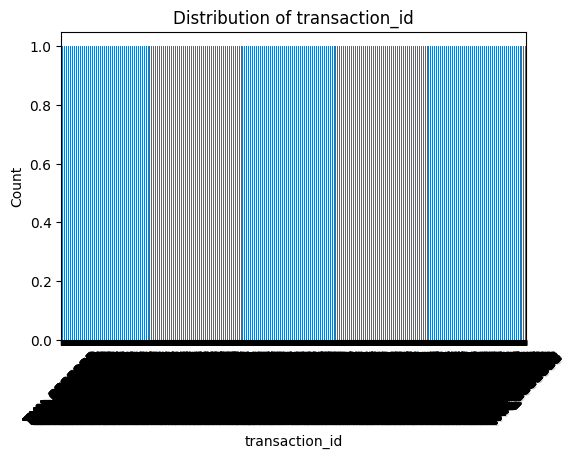

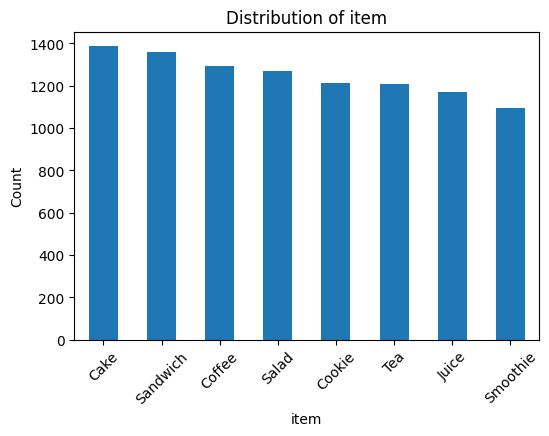

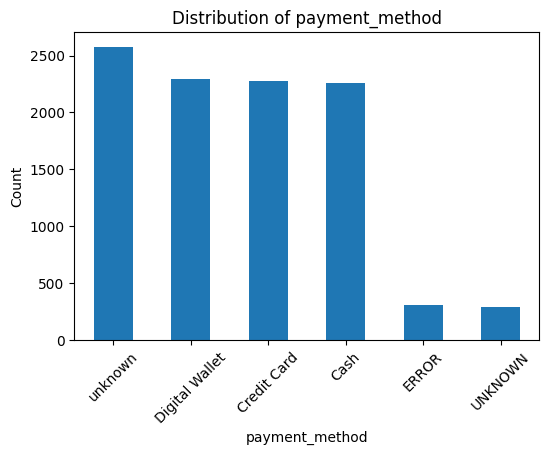

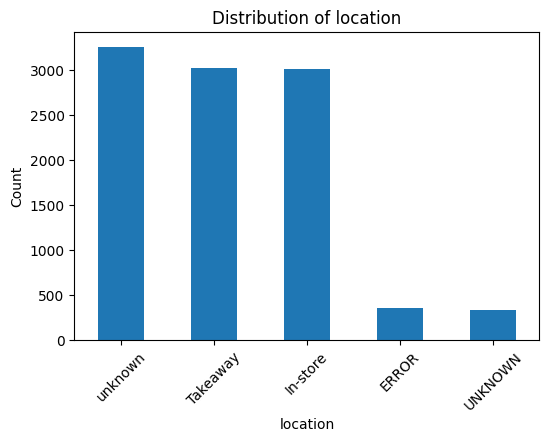

In [ ]:
import matplotlib.pyplot as plt
categorical_cols = df.select_dtypes(include=['object', 'string']).columns

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

